## Imports

In [1]:
# IMPORTS
import numpy as np
import pandas as pd
import keras
from keras import layers
import random
from keras.utils import to_categorical

DOES_BATTERY_RUN_OUT = True
UTILITY_DECREASE = 0.10   # Drop when device is selected and trains
UTILITY_INCREASE = 0.05   # Recovery when device is skipped in a round

ALPHA = 0.4

NUM_ROUNDS = 10

EPOCHS = 2

DATA_SEED = 1
RUN_SEED = 1


import tensorflow as tf
import os

def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_all_seeds(RUN_SEED)

## Classes

In [2]:
# CLASSES

class Device:
    def __init__(self, id, ram, storage, cpu, bandwidth, battery, charging):
        self.id = id
        self.ram = ram
        self.storage = storage
        self.cpu = cpu
        self.bandwidth = bandwidth
        self.battery = battery
        self.charging = charging
        self.model: keras.Sequential = Server.create_model()
        self.last_round_participated = 0
        self.data = None  # Placeholder for dataset partition
        self.test_data = None
        self.number_of_times_fitted = 0
        self.hardware_value_sum = 0.0
        
        self.utility_score: float = 1.0  # Initialize utility score to 1.0
        
    @property
    def is_off(self):
        # Battery is deprecated; utility_score is the hard participation gate
        return self.utility_score < UTILITY_DECREASE
    
    def fit(self, x_train, y_train, epochs=1, verbose=0):
        # if DOES_BATTERY_RUN_OUT:
        #     if self.battery > 0.2:
        #         self.battery -= 0.1
        #         self.model.fit(x_train, y_train, epochs=epochs, verbose=verbose)
        #     else:
        #         self.battery = 0
        #         print("device turned off!")
        # else:
            self.model.fit(x_train, y_train, epochs=epochs, verbose=verbose)
    
    def lose_battery(self):
        if self.hardware_value_sum > 0.3:
            self.hardware_value_sum -= 0.3
        else:
            self.hardware_value_sum = 0
            print("device turned off!")
        
        # if float(self.battery) > 0.3:
        #     self.battery -= 0.3
        # else:
        #     self.battery = 0
        #     print("device turned off!")

class Server:
    def __init__(self, devices_list: list[Device]):
        self.model: keras.Sequential = Server.create_model()
        self.current_learning_iteration = 0
        self.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES = []
        self.x_test_global = []
        self.y_test_global = []
        self.devices = devices_list
               
        # The variables below are used to keep track of the remaining rounds and generations and to store the variances
        # They do not logically belong to the Server class
        self.remaining_generation = 0
        self.remaining_round = 0
        self.variances = []  # List to store variances as [round, gen, solution, variance]
        self.pareto_fronts = [] # List to store pareto fronts as [round, gen, solution]

    def evaluate(self, x_test=None, y_test=None, verbose = 0):
        if x_test is None and y_test is None:
            test_loss, test_acc = self.model.evaluate(self.x_test_global, self.y_test_global, verbose)
            return test_loss, test_acc
        test_loss, test_acc = self.model.evaluate(x_test, y_test, verbose=verbose)
        return test_loss, test_acc

    def get_weights(self):
        return self.model.get_weights()

    def set_aggregated_weight(self):
        self.model.set_weight(Server.aggregate_weights())

    def give_global_model_weights_to_bitstring_devices(self, bitstring, battery_depletion=True):
            if battery_depletion:
                for device in self.devices:
                    if int(bitstring[int(device.id)]) == 1 and not device.is_off:
                        device.model.set_weights(self.model.get_weights())
            else:
                for device in self.devices:
                    if int(bitstring[int(device.id)]) == 1:
                        device.model.set_weights(self.model.get_weights())

    def create_model() -> keras.Sequential:
        model = keras.Sequential([
            layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
                        # new
                        loss='categorical_crossentropy', metrics=['accuracy'])
        return model

    def aggregate_weights(self, bitstring):
        """Computes the weighted average of model weights from all devices and updates the global model."""
        def sum_all_nested_lists(list_of_lists):
            def recursive_sum(lists):
                if isinstance(lists[0], list):
                    return [recursive_sum([lst[i] for lst in lists]) for i in range(len(lists[0]))]
                else:
                    return sum(lists)

            return recursive_sum(list_of_lists)

        def multiply_nested_list(lst, factor):
            result = []
            for item in lst:
                if isinstance(item, list):
                    # Recursively handle sublists
                    result.append(multiply_nested_list(item, factor))
                else:
                    # Multiply number
                    result.append(item * factor)
            return result

        selected_devices = []
        for device in self.devices:
            if int(bitstring[int(device.id)]) == 1 and device.is_off == False:
                selected_devices.append(device)

        num_devices = len(selected_devices)
        if num_devices == 0:
            print("No devices available for aggregation.")
            return

        # device_participation_ratio = []
        data_lengths = []

        for device in selected_devices:
            # print("*******************")
            # print(device.id)
            # device_participation_ratio.append(device.last_round_participated / self.current_learning_iteration)
            # print("this device's participation ratio:")
            # print(device.last_round_participated / self.current_learning_iteration)
            data_lengths.append(len(device.data[0]))
            # print("this device's data to all ratio:")
            # print(len(device.data[0])/60000.0)

        sum_data = 0
        for data_len in data_lengths:
            sum_data += data_len

        data_fractions = []
        for device in selected_devices:
            data_fractions.append(len(device.data[0])/float(sum_data))



        # combined_weights = [fraction * ratio for fraction, ratio in zip(data_fractions, device_participation_ratio)]
        # total_weight = sum(combined_weights)
        # normalized_weights = [w / total_weight for w in combined_weights]
        normalized_weights = data_fractions
        # print(normalized_weights)


        aggregated_weights_devices = []
        for d in range(len(selected_devices)):
            # aggregated_weights_devices.append(multiply_nested_list(selected_devices[d].model.get_weights(), data_fractions[d]*device_participation_ratio[d]))
            aggregated_weights_devices.append(multiply_nested_list(self.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(selected_devices[d].id)], normalized_weights[d]))

        aggregated_weights = sum_all_nested_lists(aggregated_weights_devices)
        # TODO: Weighted multiplication for each node in each layer of the neural network of the received devices and then summing
        #       the related parts together so that we get a full weighted average of all these devices' models

        # print("Aggregated weights:")
        # for layer_idx, layer_weights in enumerate(aggregated_weights):
            # print(f"Layer {layer_idx}: {layer_weights.shape}")
            
        
        return aggregated_weights




## Functions

In [3]:
# Functions

def fit_bitstring_devices(bitstring, server: Server, epochs=EPOCHS, skip_off=False):
    '''
    server: for using its "current_learning_iteration" variable
    '''

    server.current_learning_iteration += 1
    for device in server.devices:
        
        if int(bitstring[int(device.id)]) == 1 and (not device.is_off or skip_off):
            # device.lose_battery()
            
            device.fit(device.data[0], device.data[1], epochs=epochs, verbose=0)
            # print(device.id)
            device.last_round_participated = server.current_learning_iteration
            server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES[int(device.id)] = device.model.get_weights()
            device.number_of_times_fitted += 1
            device.utility_score = max(0.0, round(device.utility_score - UTILITY_DECREASE, 2))




def niid_labeldir_split(x_data, y_data, num_clients, beta, seed=DATA_SEED):
    num_classes = 10
    y_indices = np.array([np.argmax(label) for label in y_data])  # From one-hot to class index
    
    rng = np.random.default_rng(seed)  # Local random generator

    # Prepare client partitions
    client_indices = [[] for _ in range(num_clients)]

    for k in range(num_classes):
        idx_k = np.where(y_indices == k)[0]
        rng.shuffle(idx_k)

        # Dirichlet distribution for class k
        proportions = rng.dirichlet(np.repeat(beta, num_clients))

        # Scale proportions to match the number of available samples
        proportions = np.array([int(p * len(idx_k)) for p in proportions])
        # Fix total due to rounding
        while sum(proportions) < len(idx_k):
            proportions[np.argmin(proportions)] += 1
        while sum(proportions) > len(idx_k):
            proportions[np.argmax(proportions)] -= 1

        start = 0
        for i in range(num_clients):
            size = proportions[i]
            client_indices[i].extend(idx_k[start:start + size])
            start += size

    return client_indices



def random_hardware_value_for_devices(devices: list[Device]):
    random_values = [3.91, 0.62, 1.79, 4.96, 5.87, 2.14, 1.41, 5.18, 2.80, 3.00, 0.20, 1.02, 5.73, 0.69, 4.27,
                     5.37, 1.62, 0.93, 3.61, 2.90, 4.53, 2.13, 3.01, 0.07, 1.34, 3.90, 0.28, 1.89, 5.95, 2.76]
    
    for idx in range(len(devices)):
        devices[idx].hardware_value_sum = random_values[idx]
    
    print("Successfully gave each device a random value between 0 and 6 for its hardware objective!")


## Load Data

### Load Devices

In [4]:
# Load dataset from CSV
csv_file = 'devices.csv'
df = pd.read_csv(csv_file)
df.columns = df.columns.str.strip().str.lower()

# Convert CSV rows into device objects
devices = []

for _, row in df.iterrows():
    device = Device(
        row['id'], row['ram'], row['storage'], row['cpu'], row['bandwidth'], row['battery'],
        row.get('charging', 0)
    )
    device.utility_score = row['battery']
    devices.append(device)


# LIMIT TO 30 DEVICES
devices = devices[:30]

random_hardware_value_for_devices(devices)

d:\Github Repos\FL\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Successfully gave each device a random value between 0 and 6 for its hardware objective!


### Object Initializations

In [5]:
# Global Model
server = Server(devices_list=devices)
server.LAST_WEIGHTS_SENT_FOR_ALL_DEVICES = [None for _ in range(len(devices))]

### Split Data Among Devices

In [6]:
# np.random.seed(SEED)
# np.random.random_integers(1, 10)

In [7]:


# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Convert labels to categorical (one-hot encoded)
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Normalize data and reshape for CNN
x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)  # Add channel dimension

x_test = x_test.astype("float32") / 255.0
x_test = np.expand_dims(x_test, -1)  # Add channel dimension

# Shuffle data
# indices = np.arange(len(x_train))
# np.random.shuffle(indices)
# x_train, y_train = x_train[indices], y_train[indices]




# Lower the amount of data for devices
x_train = x_train[:int(len(x_train)/8)] # was 8
y_train = y_train[:int(len(y_train)/8)]




# Correct test split
split_index = int(0.8 * len(x_test))
x_test_devices, y_test_devices = x_test[:split_index], y_test[:split_index]
server.x_test_global, server.y_test_global = x_test[split_index:], y_test[split_index:]

# Training data (for devices)
x_train_devices, y_train_devices = x_train, y_train

# Split training data among devices
alpha = ALPHA  # lower = more skewed
num_devices = len(devices)
split_indices = niid_labeldir_split(x_train_devices, y_train_devices, num_devices, alpha, seed=DATA_SEED)

for i, device in enumerate(devices):
    idxs = split_indices[i]

    from sklearn.model_selection import train_test_split

    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(x_train_devices[idxs], y_train_devices[idxs], test_size=0.3, random_state=42)

    device.data = [X_train, y_train]
    device.test_data = [X_test, y_test]

    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)
    print("y_train shape:", y_train.shape)
    print("y_test shape:", y_test.shape)


#TODO:
# how does each objective get better through populations? maybe put em on a scale

X_train shape: (149, 28, 28, 1)
X_test shape: (64, 28, 28, 1)
y_train shape: (149, 10)
y_test shape: (64, 10)
X_train shape: (140, 28, 28, 1)
X_test shape: (60, 28, 28, 1)
y_train shape: (140, 10)
y_test shape: (60, 10)
X_train shape: (272, 28, 28, 1)
X_test shape: (117, 28, 28, 1)
y_train shape: (272, 10)
y_test shape: (117, 10)
X_train shape: (148, 28, 28, 1)
X_test shape: (64, 28, 28, 1)
y_train shape: (148, 10)
y_test shape: (64, 10)
X_train shape: (105, 28, 28, 1)
X_test shape: (45, 28, 28, 1)
y_train shape: (105, 10)
y_test shape: (45, 10)
X_train shape: (135, 28, 28, 1)
X_test shape: (58, 28, 28, 1)
y_train shape: (135, 10)
y_test shape: (58, 10)
X_train shape: (175, 28, 28, 1)
X_test shape: (76, 28, 28, 1)
y_train shape: (175, 10)
y_test shape: (76, 10)
X_train shape: (252, 28, 28, 1)
X_test shape: (108, 28, 28, 1)
y_train shape: (252, 10)
y_test shape: (108, 10)
X_train shape: (289, 28, 28, 1)
X_test shape: (125, 28, 28, 1)
y_train shape: (289, 10)
y_test shape: (125, 10)
X_tr

In [8]:
# test
a, b =devices[23].test_data
print(len(a))

66


### Load Other Data

In [9]:
import json

class FLLogger:
    def __init__(self):
        self.logs = {}
    
    def log_round(self, round_num: int, round_log: dict):
        self.logs[str(round_num)] = round_log
    
    def save_log(self, filename: str):
        with open(filename, 'w') as f:
            json.dump(self.logs, f)



## First Iteration

In [10]:
# First Iteration
bitstring = [1 for _ in range(len(devices))]
print(bitstring)

#####################
fl_logger = FLLogger()
round_logs = {}
round_logs["bitstring"] = bitstring
round_logs["selected_clients"] = [device.id for device, bit in zip(server.devices, bitstring) if bit == 1]
round_logs["num_selected_clients"] = sum(bitstring)
round_logs["participating_clients"] = [device.id for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off]
round_logs["num_participating_clients"] = len(round_logs["participating_clients"])
round_logs["average_utility_selected_clients_before_fit"]= np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1])
round_logs["average_utility_participating_clients_before_fit"] = np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off])
round_logs["per_client_utility_before_fit"] = {device.id: device.utility_score for device in server.devices}
accuracies = []
for device in server.devices:
    x_test = device.test_data[0]
    y_test = device.test_data[1]
    loss, accuracy = server.evaluate(x_test, y_test)
    accuracies.append(accuracy)
round_logs["per_client_accuracy_before_fit"] = {device.id: acc for device, acc in zip(server.devices, accuracies)}
accuracies = None
#####################

# Save weights to a file
# The file name should end in .weights.h5
# The weights can be loaded into a model using model.load_weights('model.weights.h5')
# server.model.save_weights('my_model.weights.h5')
server.model.load_weights('my_model.weights.h5')

# global model sends its weights to all devices
server.give_global_model_weights_to_bitstring_devices(bitstring, battery_depletion=False)



test_loss, test_acc = server.evaluate(verbose=0)
print(f"Global Model Accuracy: {test_acc:.2f}")
print("------------------------------------------------------------")
fit_bitstring_devices(bitstring, server, skip_off=True)
# NEW: Changed to  the code below, so all devices participate first time, even if is_off is true
for device in devices:
    device:Device
    # device.fit(device.data[0], device.data[1], epochs=EPOCHS, verbose=0)
    print(f"Device: {device.id}, Data len: {len(device.data[0])}")
    print(f"Utility score: {device.utility_score}")
    
server.model.set_weights(server.aggregate_weights(bitstring))

print("------------------------------------------------------------")
test_loss, test_acc = server.evaluate(verbose=0)
print(f"Global Model Accuracy: {test_acc:.2f}")




accuracies = []

for device in server.devices:
    x_test = device.test_data[0]
    y_test = device.test_data[1]
    
    loss, accuracy = server.evaluate(x_test, y_test)
    
    accuracies.append(accuracy)
    print(f"Device {device.id} Accuracy: {round(accuracy, 2)}")

VARIANCE = np.var(accuracies)
VARIANCE_SCORE = 1.0/VARIANCE
MEAN = np.mean(accuracies)
STANDARD_DEVIATION = np.std(accuracies)
FAIRNESS = 1.0/STANDARD_DEVIATION
###################################################
round_logs["average_utility_selected_clients_after_fit"]= np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1])
round_logs["average_utility_participating_clients_after_fit"] = np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off])
round_logs["per_client_utility_after_fit"] = {device.id: device.utility_score for device in server.devices}
round_logs["global_test_accuracy"] = test_acc
round_logs["mean_client_accuracy"] = MEAN
round_logs["fairness"] = FAIRNESS
round_logs["worst_client_accuracy"] = min(accuracies)
###################################################


fl_logger.log_round("warm_up", round_logs)
round_logs = None

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0936 - loss: 2.3327
Global Model Accuracy: 0.09
------------------------------------------------------------
Device: 0.0, Data len: 149
Utility score: 0.0
Device: 1.0, Data len: 140
Utility score: 0.8
Device: 2.0, Data len: 272
Utility score: 0.41
Device: 3.0, Data len: 148
Utility score: 0.73
Device: 4.0, Data len: 105
Utility score: 0.22
Device: 5.0, Data len: 135
Utility score: 0.8
Device: 6.0, Data len: 175
Utility score: 0.29
Device: 7.0, Data len: 252
Utility score: 0.0
Device: 8.0, Data len: 289
Utility score: 0.81
Device: 9.0, Data len: 242
Utility score: 0.0
Device: 10.0, Data len: 185
Utility score: 0.22
Device: 11.0, Data len: 52
Utility score: 0.85
Device: 12.0, Data len: 130
Utility score: 0.85
Device: 13.0, Data len: 233
Utility score: 0.47
Device: 14.0, Data len: 228
Utility score: 0.53
Device: 15.0, Data len: 347
Utility score: 

## FL Loop

In [11]:
# Parameters
print(f"NUM_ROUNDS: {NUM_ROUNDS}")

server.remaining_round = NUM_ROUNDS

NUM_ROUNDS: 10


In [12]:
# DEBUG:
print(server.x_test_global.shape)
print(server.y_test_global.shape)

print(x_train.shape)
print(y_train.shape)

(2000, 28, 28, 1)
(2000, 10)
(7500, 28, 28, 1)
(277, 10)


In [13]:
import random

def generate_binary_list(n: int, percent_ones: float):
    """
    Generate a list of n random binary numbers (0s and 1s),
    where approximately 'percent_ones' fraction are 1s.

    Args:
        n (int): Total number of elements in the list.
        percent_ones (float): Fraction (0.0 to 1.0) indicating what percent should be 1s.

    Returns:
        list[int]: Randomized list of 0s and 1s.
    """
    if not (0 <= percent_ones <= 1):
        raise ValueError("percent_ones must be between 0.0 and 1.0")

    # Determine number of ones
    num_ones = int(round(n * percent_ones))
    num_zeros = n - num_ones

    # Create the list
    binary_list = [1] * num_ones + [0] * num_zeros

    # Shuffle for randomness
    random.shuffle(binary_list)

    return binary_list


In [14]:
lst = generate_binary_list(30, 0.25)
print(lst)
print(lst.count(1))

[1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0]
8


In [15]:
all_runs_fronts = []  # Stores results across runs
all_runs_solutions = []

VARIANCES = []

needed_values_for_comparison = ""

for i in range(NUM_ROUNDS):
    ##########################
    round_logs = {}
    ##########################
    server.remaining_round = NUM_ROUNDS - i

    # Generate bitstring
    bitstring = generate_binary_list(len(devices), 0.25)
    ###############################
    print(bitstring)
    print(bitstring[0])
    print(type(bitstring[0]))
    
    ###############################
    round_logs["bitstring"] = bitstring
    round_logs["selected_clients"] = [device.id for device, bit in zip(server.devices, bitstring) if bit == 1]
    round_logs["num_selected_clients"] = sum(bitstring)
    round_logs["participating_clients"] = [device.id for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off]
    round_logs["num_participating_clients"] = len(round_logs["participating_clients"])
    round_logs["average_utility_selected_clients_before_fit"]= np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1])
    round_logs["average_utility_participating_clients_before_fit"] = np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off])
    round_logs["per_client_utility_before_fit"] = {device.id: device.utility_score for device in server.devices}
    accuracies = []
    for device in server.devices:
        x_test = device.test_data[0]
        y_test = device.test_data[1]
        loss, accuracy = server.evaluate(x_test, y_test)
        accuracies.append(accuracy)
    
    round_logs["per_client_accuracy_before_fit"] = {device.id: acc for device, acc in zip(server.devices, accuracies)}
    accuracies = None
    #################################
    
    # global model sends its weights to all devices
    server.give_global_model_weights_to_bitstring_devices(bitstring)

    test_loss, test_acc = server.evaluate(verbose=0)
    print(f"Global Model Accuracy: {test_acc:.2f}")
    print("------------------------------------------------------------")
    fit_bitstring_devices(bitstring, server)
    weights = server.aggregate_weights(bitstring)
    if weights:
        server.model.set_weights(weights)
    
    for device in server.devices:
        if device.last_round_participated != server.current_learning_iteration:
            device.utility_score = min(1.0, round(device.utility_score + UTILITY_INCREASE, 2))
    print("------------------------------------------------------------")
    test_loss, test_acc = server.evaluate(verbose=0)
    print(f"Global Model Accuracy: {test_acc:.2f}")
    
    # ---
    
    accuracies = []

    for device in server.devices:
        x_test = device.test_data[0]
        y_test = device.test_data[1]
        
        loss, accuracy = server.evaluate(x_test, y_test)
        
        accuracies.append(round(accuracy, 2))
        print(f"Device {device.id} Accuracy: {round(accuracy, 2)}")
        print(f"Data len: {len(device.data[0])}")
        print(f"Device {device.id} Utility Score: {device.utility_score}")
        print(f"Device {device.id} Last Round Participated: {device.last_round_participated}")

    VARIANCE = np.var(accuracies)
    VARIANCE_SCORE = 1.0/VARIANCE
    MEAN = np.mean(accuracies)
    STANDARD_DEVIATION = np.std(accuracies)
    FAIRNESS = 1.0/STANDARD_DEVIATION
    
    needed_values_for_comparison += f"Round: {i+1}\nServer Test Accuracy: {test_acc}\nVariance: {VARIANCE}\nVariance Score: {VARIANCE_SCORE}\nMean: {MEAN}\nStandard Deviation: {STANDARD_DEVIATION}\nFairness: {FAIRNESS}\n---\n"
    
    
    
    ###################################################
    round_logs["average_utility_selected_clients_after_fit"]= np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1])
    round_logs["average_utility_participating_clients_after_fit"] = np.mean([device.utility_score for device, bit in zip(server.devices, bitstring) if bit == 1 and not device.is_off])
    round_logs["per_client_utility_after_fit"] = {device.id: device.utility_score for device in server.devices}
    round_logs["global_test_accuracy"] = test_acc
    round_logs["mean_client_accuracy"] = MEAN
    round_logs["fairness"] = FAIRNESS
    round_logs["worst_client_accuracy"] = min(accuracies)
    ###################################################
    
    
    fl_logger.log_round(i+1, round_logs)
    round_logs = None

[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1]
0
<class 'int'>
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1016 - loss: 2.2664
Global Model Accuracy: 0.10
------------------------------------------------------------
------------------------------------------------------------
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1976 - loss: 2.1850
Global Model Accuracy: 0.19
Device 0.0 Accuracy: 0.03
Data len: 149
Device 0.0 Utility Score: 0.05
Device 0.0 Last Round Participated: 1
Device 1.0 Accuracy: 0.15
Data len: 140
Device 1.0 Utility Score: 0.85
Device 1.0 Last Round Participated: 1
Device 2.0 Accuracy: 0.32
Data len: 272
Device 2.0 Utility Score: 0.46
Device 2.0 Last Round Participated: 1
Device 3.0 Accuracy: 0.03
Data len: 148
Device 3.0 Utility Score: 0.78
Device 3.0 Last Round Participated: 1
Device 4.0 Accuracy: 0.29
Data len: 105
Device 4.0 Utility Score: 0.27
Device 4.0 Last Round Participated: 1
Device 5.0 Accuracy: 0.2

In [16]:
## Save FL Logs
fl_logger.save_log(f"25p_random_alpha{ALPHA}_runseed{RUN_SEED}_dataseed{DATA_SEED}_logs.json")

In [17]:
print(server.evaluate())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5764 - loss: 1.1099
(1.1082018613815308, 0.574999988079071)


In [18]:
accuracies = []

for device in server.devices:
    x_test = device.test_data[0]
    y_test = device.test_data[1]
    
    loss, accuracy = server.evaluate(x_test, y_test)
    
    accuracies.append(round(accuracy, 2))
    print(f"Device {device.id} Accuracy: {round(accuracy, 2)}")

VARIANCE = np.var(accuracies)
VARIANCE_SCORE = 1.0/VARIANCE
MEAN = np.mean(accuracies)
STANDARD_DEVIATION = np.std(accuracies)

Device 0.0 Accuracy: 0.11
Device 1.0 Accuracy: 0.5
Device 2.0 Accuracy: 0.71
Device 3.0 Accuracy: 0.86
Device 4.0 Accuracy: 0.56
Device 5.0 Accuracy: 0.43
Device 6.0 Accuracy: 0.51
Device 7.0 Accuracy: 0.65
Device 8.0 Accuracy: 0.85
Device 9.0 Accuracy: 0.56
Device 10.0 Accuracy: 0.43
Device 11.0 Accuracy: 0.57
Device 12.0 Accuracy: 0.75
Device 13.0 Accuracy: 0.47
Device 14.0 Accuracy: 0.87
Device 15.0 Accuracy: 0.71
Device 16.0 Accuracy: 0.62
Device 17.0 Accuracy: 0.17
Device 18.0 Accuracy: 0.45
Device 19.0 Accuracy: 0.36
Device 20.0 Accuracy: 0.48
Device 21.0 Accuracy: 0.68
Device 22.0 Accuracy: 0.47
Device 23.0 Accuracy: 0.64
Device 24.0 Accuracy: 0.49
Device 25.0 Accuracy: 0.46
Device 26.0 Accuracy: 0.26
Device 27.0 Accuracy: 0.55
Device 28.0 Accuracy: 0.48
Device 29.0 Accuracy: 0.37


In [19]:
print(f"MEAN: {MEAN}")
print(f"VARIANCE: {VARIANCE}")
print(f"STANDARD_DEVIATION: {STANDARD_DEVIATION}")
print(f"Fairness: {1.0/STANDARD_DEVIATION}")

MEAN: 0.5340000000000001
VARIANCE: 0.03267733333333333
STANDARD_DEVIATION: 0.1807687288590959
Fairness: 5.531930253154967


In [20]:
print(needed_values_for_comparison)

Round: 1
Server Test Accuracy: 0.19499999284744263
Variance: 0.031967666666666665
Variance Score: 31.28160745753522
Mean: 0.21300000000000002
Standard Deviation: 0.17879504094539833
Fairness: 5.592996286207887
---
Round: 2
Server Test Accuracy: 0.33250001072883606
Variance: 0.051240555555555546
Variance Score: 19.51579152797806
Mean: 0.32833333333333325
Standard Deviation: 0.22636376820409124
Fairness: 4.417668109758593
---
Round: 3
Server Test Accuracy: 0.3880000114440918
Variance: 0.027956
Variance Score: 35.77049649449134
Mean: 0.3720000000000001
Standard Deviation: 0.16720047846821492
Fairness: 5.980844128924557
---
Round: 4
Server Test Accuracy: 0.29750001430511475
Variance: 0.05935833333333332
Variance Score: 16.846834199073427
Mean: 0.275
Standard Deviation: 0.24363565694153497
Fairness: 4.104489517476373
---
Round: 5
Server Test Accuracy: 0.46950000524520874
Variance: 0.044256555555555556
Variance Score: 22.595522571671744
Mean: 0.4336666666666667
Standard Deviation: 0.21037242

In [21]:
accuracy_plot_x = []
accuracy_plot_y = []

for item in needed_values_for_comparison.split("---")[:-1]:
    for subitem in item.split("\n"):
        if "Server Test Accuracy" in subitem:
            print(float(subitem[subitem.find(": ")+2:]))
            accuracy_plot_y.append(float(subitem[subitem.find(": ")+2:]))
        
    accuracy_plot_x.append(needed_values_for_comparison.split("---").index(item)+1)
        
print(accuracy_plot_x)
print(accuracy_plot_y)

0.19499999284744263
0.33250001072883606
0.3880000114440918
0.29750001430511475
0.46950000524520874
0.4984999895095825
0.5649999976158142
0.6255000233650208
0.5734999775886536
0.574999988079071
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[0.19499999284744263, 0.33250001072883606, 0.3880000114440918, 0.29750001430511475, 0.46950000524520874, 0.4984999895095825, 0.5649999976158142, 0.6255000233650208, 0.5734999775886536, 0.574999988079071]


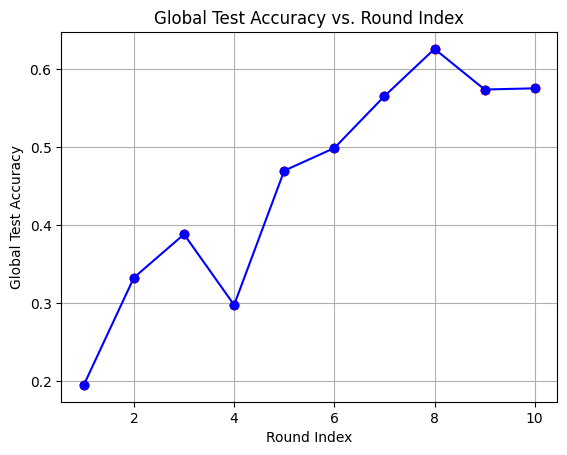

In [22]:
import matplotlib.pyplot as plt

# Example points (replace with your own x and y values)
x = accuracy_plot_x
y = accuracy_plot_y

# Scatter plot of points
plt.scatter(x, y, color='red', zorder=2)

# Plot line with markers
plt.plot(x, y, marker='o', linestyle='-', color='blue')

# Highlight the points explicitly if you like
plt.scatter(x, y, color='red')

plt.xlabel("Round Index")
plt.ylabel("Global Test Accuracy")
plt.title("Global Test Accuracy vs. Round Index")
plt.grid(True)
plt.show()
